# Depth measurements in time (Depth Anything v3)

In [1]:
import numpy as np

In [2]:
import pandas as pd

In [3]:
import cv2

In [4]:
from natsort import natsorted

In [5]:
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from matplotlib.colors import ListedColormap
# from mpl_interactions import hyperslicer
# %matplotlib ipympl

In [6]:
from tqdm import tqdm

In [7]:
import os

In [8]:
import torch
from depth_anything_3.api import DepthAnything3

[WARN ] Dependency `gsplat` is required for rendering 3DGS. Install via: pip install git+https://github.com/nerfstudio-project/gsplat.git@0b4dddf04cb687367602c01196913cde6a743d70


In [9]:
from PIL import Image

## Model setup

In [10]:
device = torch.device("cuda")

In [11]:
model_name = "depth-anything/DA3-BASE"

In [12]:
model = DepthAnything3.from_pretrained(model_name)

[INFO ] using MLP layer as FFN


In [13]:
model = model.to(device=device)

## IO

In [14]:
images_path = "../../../../data/depth_measurements/dormakaba/20251210_091129_68a65263//"

In [15]:
images = []
for img_path in natsorted(os.listdir(images_path)):
    img = Image.open(images_path + img_path)
    images.append(np.array(img))

In [16]:
sample_img = Image.open(images_path + "full_image_000015.png")
print(f"Sample image: {sample_img.width}x{sample_img.height}")

Sample image: 2104x1560


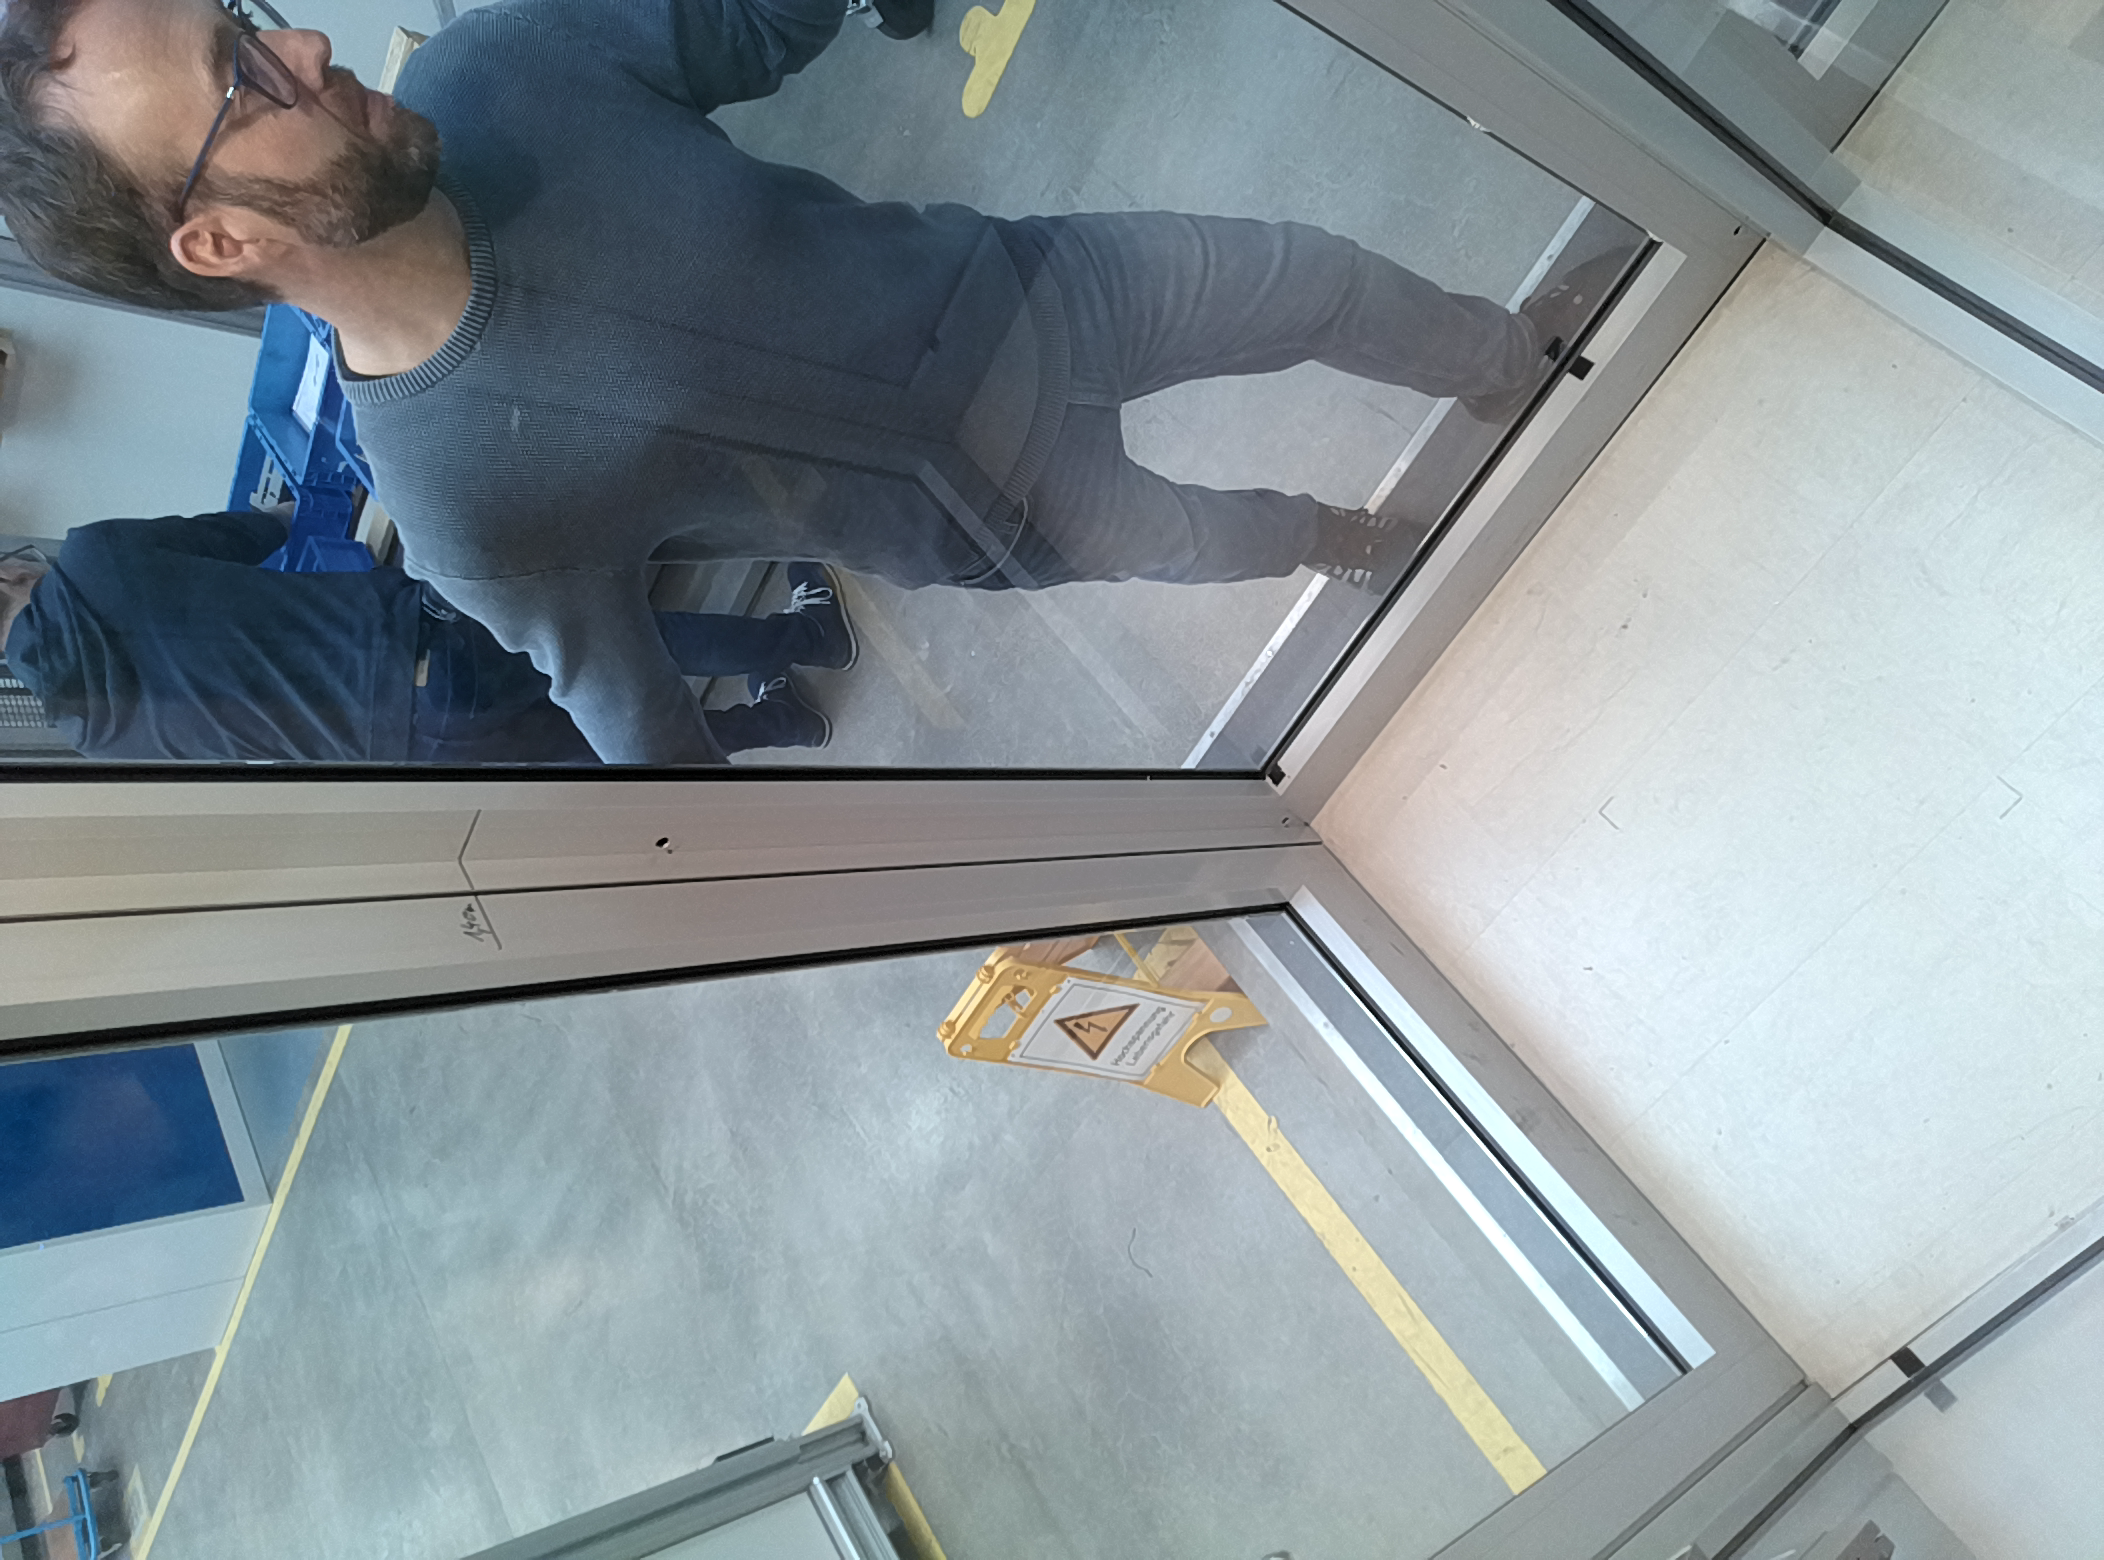

In [17]:
sample_img

## Camera setup

- **Camera intrinsics**
    - Effective image resolution (`cam_intriniscs[0, 0]`, `cam_intrinsics[1, 1]`)
        - Sensor resolution is higher but in OAK-D Lite some of the sensor pixels are not used to produce the image but for processing, therefore asking for `cam.requestFullResolutionOutput()` produces images with shape (2104x1560)
    - Center camera offset (`cam_intriniscs[0, 2]`, `cam_intriniscs[1, 2]`)
        - Camera center is offsetted by some pixels    
- **Camera extrinsics**
    - Camera rotation matrix to map 3D point coordinates to camera reference frame. It is computed from Camera attitude (camera pose) with roll, pitch and yaw values.

In [18]:
n_images = len(images)
n_images

30

In [19]:
def compute_rotated_intrinsics(K, W, H, angle_deg=90):
    """
    Returns K' = M K, where M is a rotation of the image plane by +90° CCW
    around the image center (W,H).
    """
    theta = np.deg2rad(angle_deg)

    # 2D rotation matrix
    R = np.array([
        [np.cos(theta), -np.sin(theta)],
        [np.sin(theta),  np.cos(theta)]
    ])

    # image center to rotate around
    C = np.array([W/2, H/2])

    # translation so rotation happens around center, not origin
    t = C - R @ C

    # build full 3×3 image-plane transform
    M = np.eye(3)
    M[0:2, 0:2] = R
    M[0:2, 2] = t

    # combined intrinsic matrix
    Kp = M @ K
    return Kp


In [20]:
cam_intrinsics = np.array([
[1498.00,    0.0, 1040.0],
[   0.0, 1494.0,  772.0],
[   0.0,    0.0,    1.0]])

W = 2104  # width in pixels
H = 1560  # height in pixels

# Compute K'
Kp = compute_rotated_intrinsics(cam_intrinsics, W, H, angle_deg=90)
cam_intrinsics = Kp

intrinsics = np.tile(cam_intrinsics, (n_images, 1, 1))

In [21]:
intrinsics.shape

(30, 3, 3)

In [22]:
w2c_extrinsics = np.array([
    [5.00000000e-01,  5.00000000e-01,  7.07106781e-01, -1.44249783e+03],
    [ 7.07106781e-01, -7.07106781e-01, -4.32978028e-17, 8.83275177e-14],
    [ 5.00000000e-01,  5.00000000e-01, -7.07106781e-01,  1.44249783e+03],
    [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  1.00000000e+00]
])

In [23]:
w2c_extrinsics.shape

(4, 4)

In [24]:
c2w_extrinsics = np.linalg.inv(w2c_extrinsics)
c2w_extrinsics

array([[ 5.00000000e-01,  7.07106781e-01,  5.00000000e-01,
         5.62132339e-14],
       [ 5.00000000e-01, -7.07106781e-01,  5.00000000e-01,
         5.62132342e-14],
       [ 7.07106781e-01, -0.00000000e+00, -7.07106781e-01,
         2.04000000e+03],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         1.00000000e+00]])

In [25]:
cam_extrinsics = w2c_extrinsics

extrinsics = np.tile(cam_extrinsics, (n_images, 1, 1))

## Inference

In [26]:
prediction = model.inference(images,
    export_dir="output",
    extrinsics=extrinsics,
    intrinsics=intrinsics,
)

[INFO ] Processed Images Done taking 0.21449756622314453 seconds. Shape:  torch.Size([30, 3, 378, 504])
[INFO ] Using camera conditions provided by the user
[INFO ] Model Forward Pass Done. Time: 0.9549567699432373 seconds
[INFO ] Conversion to Prediction Done. Time: 0.020316123962402344 seconds
[INFO ] Export Results Done. Time: 0.0003654956817626953 seconds


In [27]:
import numpy as np
import cv2

def resize_depth_batch(depth_batch: np.ndarray, orig_size: tuple[int, int]) -> np.ndarray:
    """
    Resize a batch of depth maps to the original image size.

    Args:
        depth_batch: NumPy array of shape (N, H, W)
        orig_size: (width, height) of the original input image

    Returns:
        Resized depth maps as NumPy array of shape (N, H_orig, W_orig)
    """
    N = depth_batch.shape[0]
    orig_w, orig_h = orig_size
    resized_batch = np.zeros((N, orig_h, orig_w), dtype=np.float32)

    for i in range(N):
        resized_batch[i] = cv2.resize(
            depth_batch[i].astype(np.float32),
            (orig_w, orig_h),  # cv2 uses (width, height)
            interpolation=cv2.INTER_LINEAR
        )

    return resized_batch



In [28]:
resized_depth = resize_depth_batch(prediction.depth, orig_size=(img.width, img.height))

In [29]:
resized_depth.shape

(30, 1560, 2104)

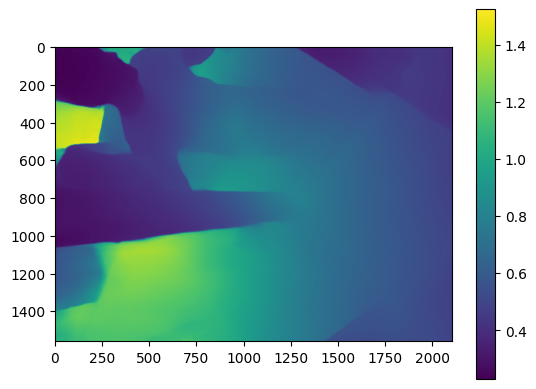

In [30]:
plt.imshow(resized_depth[15])
plt.colorbar()
plt.show()

In [31]:
point_ids = ["P0", "C0", "P1", "P2", "P3", "PE"]
x_img =  [2100, 0, 1758, 1351, 1833, 460]
y_img =  [1500, 0, 309, 836, 1358, 857]

In [32]:
data = {
    "point_id": point_ids,
    "x_world": [0, 0, 1040, 1040, 0, 1040],
    "y_world": [0, 0, 0, 1040, 1040, 1040],
    "z_world": [0, 2030, 0, 0, 0, 1400],
    "u": x_img,
    "v": y_img,
}

In [33]:
df = pd.DataFrame(data)

In [34]:
idx = 15
depth = resized_depth[idx]

In [35]:
# Calculate distance from C0 (skip C0 itself)
C0_coords = np.array([0, 0, 2030])
df["distance"] = df.apply(
    lambda row: np.linalg.norm(np.array([row["x_world"], row["y_world"], row["z_world"]]) - C0_coords),
    axis=1
)

In [36]:
df["depth_level"] = df.apply(
    lambda row: depth[int(row["v"]), int(row["u"])]
                if not pd.isna(row["u"]) and not pd.isna(row["v"]) else np.nan,
    axis=1
)

In [37]:
# Rank by distance (ascending) and depth_level (ascending)
df['distance_rank'] = df['distance'].rank(method='min', ascending=True)
df['depth_rank'] = df['depth_level'].rank(method='min', ascending=True)
df['rank_match'] = df.apply(lambda row: True if row['distance_rank'] == row['depth_rank'] else False, axis=1)
df_sorted = df.sort_values(by=['distance_rank', 'depth_rank']).reset_index(drop=True)

In [38]:
df_sorted

,point_id,x_world,y_world,z_world,u,v,distance,depth_level,distance_rank,depth_rank,rank_match
0,C0,0,0,2030,0,0,0.000000,0.306516,1.0,1.0,True
1,PE,1040,1040,1400,460,857,1600.031250,0.374419,2.0,2.0,True
2,P0,0,0,0,2100,1500,2030.000000,0.493773,3.0,3.0,True
3,P1,1040,0,0,1758,309,2280.898946,0.544821,4.0,4.0,True
4,P3,0,1040,0,1833,1358,2280.898946,0.565686,4.0,5.0,False
5,P2,1040,1040,0,1351,836,2506.810723,0.766658,6.0,6.0,True


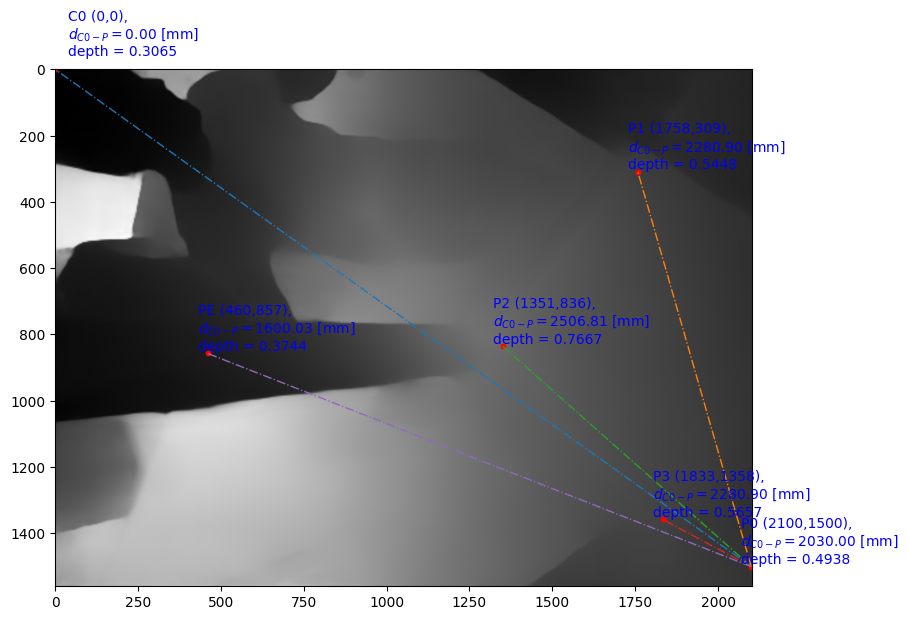

In [39]:
fig, ax = plt.subplots(figsize=(9, 9))
ax.imshow(depth, cmap="grey")
ax.scatter(df["u"], df["v"], marker='o', s=10, c="red")

# Plot lines from P0 (assume P0 is first row) to other points
x0, y0 = df.loc[0, "u"], df.loc[0, "v"]

for idx, (point_id, x, y, dist, depth_value) in enumerate(zip(df["point_id"], df["u"], df["v"], df["distance"], df["depth_level"])):
    # Skip line for P0 itself
    if idx != 0:
        ax.plot([x0, x], [y0, y], '-.', linewidth=1)
        
    # Offset label for C0 to avoid overlap
    if idx == 1:  # C0
        label_x = x + 40
        label_y = y - 40
    else:
        label_x = x - 30
        label_y = y - 10
    
    ax.text(label_x, label_y, f"{point_id} ({x},{y}),\n$d_{{{{C0}}-P}} = {dist:.2f}$ [mm]\ndepth = {depth_value:.4f}", color='b')


plt.show()

## Red zone

In [40]:
df_sorted

,point_id,x_world,y_world,z_world,u,v,distance,depth_level,distance_rank,depth_rank,rank_match
0,C0,0,0,2030,0,0,0.000000,0.306516,1.0,1.0,True
1,PE,1040,1040,1400,460,857,1600.031250,0.374419,2.0,2.0,True
2,P0,0,0,0,2100,1500,2030.000000,0.493773,3.0,3.0,True
3,P1,1040,0,0,1758,309,2280.898946,0.544821,4.0,4.0,True
4,P3,0,1040,0,1833,1358,2280.898946,0.565686,4.0,5.0,False
5,P2,1040,1040,0,1351,836,2506.810723,0.766658,6.0,6.0,True


In [41]:
def project_points_world_to_image(points_world, w2c, K):
    """
    points_world : (N, 3) array
    w2c          : (4, 4) world-to-camera matrix
    K            : (3, 3) intrinsic matrix
    returns      : (N, 2) pixel coordinates
    """

    # Convert to homogeneous (N, 4)
    ones = np.ones((points_world.shape[0], 1))
    points_h = np.hstack([points_world, ones])      # (N,4)

    # Camera coordinates: Pc = w2c @ Pw
    points_cam = (w2c @ points_h.T).T               # (N,4)

    # Extract X, Y, Z
    Xc = points_cam[:, 0]
    Yc = points_cam[:, 1]
    Zc = points_cam[:, 2]

    # Avoid division by zero
    Zc[Zc == 0] = 1e-6

    # Normalize
    x = Xc / Zc
    y = Yc / Zc

    
    # Apply intrinsics
    u = K[0,0] * x + K[0,2]
    v = K[1,1] * y + K[1,2]
    
    # Stack into (N, 2)
    return np.vstack([u, v]).T

In [42]:
df_ref = df[~df["point_id"].isin(["C0", "P0"])]
df_ref

,point_id,x_world,y_world,z_world,u,v,distance,depth_level,distance_rank,depth_rank,rank_match
2,P1,1040,0,0,1758,309,2280.898946,0.544821,4.0,4.0,True
3,P2,1040,1040,0,1351,836,2506.810723,0.766658,6.0,6.0,True
4,P3,0,1040,0,1833,1358,2280.898946,0.565686,4.0,5.0,False
5,PE,1040,1040,1400,460,857,1600.031250,0.374419,2.0,2.0,True


In [43]:
ref_points_world = df_ref.loc[:, "x_world":"z_world"]
ref_points_world

,x_world,y_world,z_world
2,1040,0,0
3,1040,1040,0
4,0,1040,0
5,1040,1040,1400


In [44]:
ref_points_world.shape

(4, 3)

In [45]:
np.array(ref_points_world)

array([[1040,    0,    0],
       [1040, 1040,    0],
       [   0, 1040,    0],
       [1040, 1040, 1400]])

In [46]:
np.set_printoptions(precision=3, suppress=True)

In [47]:
w2c_extrinsics

array([[    0.5  ,     0.5  ,     0.707, -1442.498],
       [    0.707,    -0.707,    -0.   ,     0.   ],
       [    0.5  ,     0.5  ,    -0.707,  1442.498],
       [    0.   ,     0.   ,     0.   ,     1.   ]])

In [48]:
# compute projections
projected_points = project_points_world_to_image(ref_points_world, w2c_extrinsics, cam_intrinsics)
df_ref["u_from_world"] = projected_points[:, 0].astype(int)
df_ref["v_from_world"] = projected_points[:, 1].astype(int)

In [49]:
df_ref

,point_id,x_world,y_world,z_world,u,v,distance,depth_level,distance_rank,depth_rank,rank_match,u_from_world,v_from_world
2,P1,1040,0,0,1758,309,2280.898946,0.544821,4.0,4.0,True,1060,768
3,P2,1040,1040,0,1351,836,2506.810723,0.766658,6.0,6.0,True,1060,768
4,P3,0,1040,0,1833,1358,2280.898946,0.565686,4.0,5.0,False,1060,768
5,PE,1040,1040,1400,460,857,1600.031250,0.374419,2.0,2.0,True,1060,768


In [50]:
fx = cam_intrinsics[0, 0]
fy = cam_intrinsics[1, 1]

In [51]:
# compute projection error
df_ref["u_error"] = df_ref["u"] - df_ref["u_from_world"]
df_ref["v_error"] = df_ref["v"] - df_ref["v_from_world"]
df_ref["u_error_mm"] = (df_ref["distance"] / fx) * df_ref["u_error"]
df_ref["v_error_mm"] = (df_ref["distance"] / fy) * df_ref["v_error"]

In [52]:
df_ref["u_error_mm"].describe()

count    4.000000e+00
mean     8.516298e+18
std      1.358199e+19
min     -1.046615e+19
25%      3.348087e+18
50%      1.265480e+19
75%      1.782301e+19
max      1.922175e+19
Name: u_error_mm, dtype: float64

In [53]:
df_ref["v_error_mm"].describe()

count    4.000000e+00
mean     1.671557e+18
std      1.067845e+19
min     -1.144425e+19
25%     -1.693585e+18
50%      1.710003e+18
75%      5.075145e+18
max      1.471047e+19
Name: v_error_mm, dtype: float64

In [54]:
aabb_world = np.array([
    [0, 0, 0],
    [1540, 0, 0], 
    [0, 1540, 0],
    [1540, 1540, 0], 
    [0, 0, 1400],
    [1540, 0, 1400], 
    [0, 1540, 1400],
    [1540, 1540, 1400], 
])

In [55]:
aabb_world.shape

(8, 3)

In [56]:
aabb_img = project_points_world_to_image(aabb_world, w2c_extrinsics, cam_intrinsics)

In [57]:
u_aabb = aabb_img[:, 0]
v_aabb = aabb_img[:, 1]

In [58]:
faces = [
    [0, 1, 3, 2],  # bottom  (z = 0)
    [4, 5, 7, 6],  # top     (z = 2000)

    [0, 1, 5, 4],  # front  (y = 0)
    [2, 3, 7, 6],  # back   (y = 1040)

    [0, 2, 6, 4],  # left   (x = 0)
    [1, 3, 7, 5],  # right  (x = 1040)
]

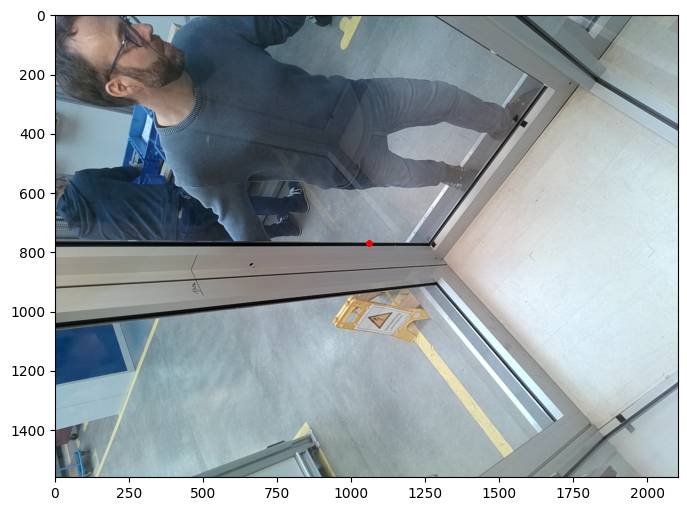

In [59]:
idx = 15
fig, ax = plt.subplots(figsize=(12, 6))

# img
ax.imshow(images[idx])

# reference points
ax.scatter(df_ref["u_from_world"], df_ref["v_from_world"], s=2, c="blue")

# axis aligned bbox vertices
ax.scatter(u_aabb, v_aabb, s=10, c="red")

for f in faces:
    poly = Polygon(aabb_img[f], closed=True, edgecolor='red', facecolor='red', alpha=0.1)
    ax.add_patch(poly)

plt.show()

In [60]:
df

,point_id,x_world,y_world,z_world,u,v,distance,depth_level,distance_rank,depth_rank,rank_match
0,P0,0,0,0,2100,1500,2030.000000,0.493773,3.0,3.0,True
1,C0,0,0,2030,0,0,0.000000,0.306516,1.0,1.0,True
2,P1,1040,0,0,1758,309,2280.898946,0.544821,4.0,4.0,True
3,P2,1040,1040,0,1351,836,2506.810723,0.766658,6.0,6.0,True
4,P3,0,1040,0,1833,1358,2280.898946,0.565686,4.0,5.0,False
5,PE,1040,1040,1400,460,857,1600.031250,0.374419,2.0,2.0,True


In [61]:
# compute scale nearby the center of the image frame
depth_to_metric_scale = 2280.898946 / resized_depth[0, 1358, 1833]
depth_to_metric_scale

4087.407895986674

In [62]:
depth = resized_depth[idx] * float(depth_to_metric_scale)

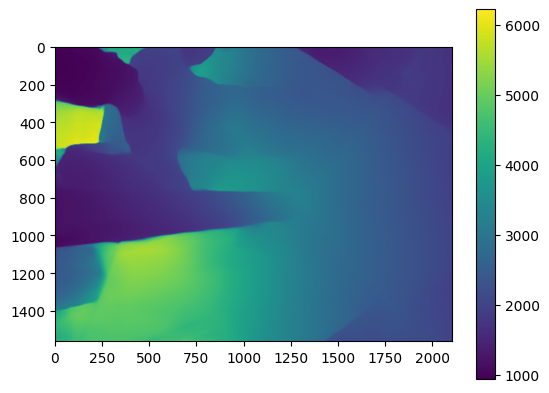

In [63]:
plt.imshow(depth)
plt.colorbar()

## Red zone check

In [64]:
h, w = depth.shape

In [65]:
# Create pixel grid
u_grid = np.arange(w)
v_grid = np.arange(h)
uu, vv = np.meshgrid(u_grid, v_grid) 

In [66]:
def project_points_image_to_world(u, v, depth, K, w2c):
    """
    u, v      : pixel coordinates (can be arrays of shape (N,))
    depth     : depth in same units as world (meters or mm) at each pixel
    K         : 3x3 camera intrinsics
    w2c       : 4x4 world-to-camera matrix
    returns   : Nx3 world coordinates
    """
    # Convert depth to float array
    depth = np.asarray(depth, dtype=float)
    u = np.asarray(u, dtype=float)
    v = np.asarray(v, dtype=float)
    
    fx = K[0,0]
    fy = K[1,1]
    cx = K[0,2]
    cy = K[1,2]
    
    # Back-project to camera coordinates
    Xc = (u - cx) * depth / fx
    Yc = (v - cy) * depth / fy
    Zc = depth
    
    # Stack homogeneous coordinates
    points_cam_h = np.stack([Xc, Yc, Zc, np.ones_like(Zc)], axis=-1)  # Nx4
    
    # Invert w2c to get camera-to-world
    c2w = np.linalg.inv(w2c)
    
    # World coordinates
    points_world_h = (c2w @ points_cam_h.T).T  # Nx4
    points_world = points_world_h[:, :3]
    
    return points_world

In [67]:
depths_points_world = []
for depth in tqdm(resized_depth):
    depth *= float(depth_to_metric_scale)
    depth_points_world = project_points_image_to_world(
        uu.ravel(), vv.ravel(), depth.ravel(),
        K=cam_intrinsics, w2c=w2c_extrinsics
    )
    depth_points_world = depth_points_world.reshape(h, w, 3)
    depths_points_world.append(depth_points_world)
depths_points_world = np.array(depths_points_world)

100%|██████████████████████████████████████████████████████| 30/30 [00:03<00:00,  8.67it/s]


In [68]:
depths_points_world.shape

(30, 1560, 2104, 3)

In [69]:
depths_points_world

array([[[[-1.427e+19,  1.927e+17, -9.953e+18],
         [-1.426e+19,  1.993e+17, -9.944e+18],
         [-1.420e+19,  2.052e+17, -9.896e+18],
         ...,
         [-4.389e+17,  1.946e+19,  1.345e+19],
         [-4.315e+17,  1.955e+19,  1.352e+19],
         [-4.223e+17,  1.956e+19,  1.353e+19]],

        [[-1.426e+19,  1.833e+17, -9.953e+18],
         [-1.425e+19,  1.899e+17, -9.944e+18],
         [-1.419e+19,  1.958e+17, -9.896e+18],
         ...,
         [-4.259e+17,  1.945e+19,  1.345e+19],
         [-4.184e+17,  1.954e+19,  1.352e+19],
         [-4.093e+17,  1.955e+19,  1.353e+19]],

        [[-1.421e+19,  1.734e+17, -9.927e+18],
         [-1.421e+19,  1.800e+17, -9.918e+18],
         [-1.415e+19,  1.860e+17, -9.871e+18],
         ...,
         [-4.116e+17,  1.937e+19,  1.341e+19],
         [-4.039e+17,  1.945e+19,  1.347e+19],
         [-3.948e+17,  1.946e+19,  1.348e+19]],

        ...,

        [[ 1.116e+18, -4.134e+19, -2.844e+19],
         [ 1.135e+18, -4.132e+19, -2.842e+19]

In [70]:
aabb_world.min(axis=0)

array([0, 0, 0])

In [71]:
aabb_world.max(axis=0)

array([1540, 1540, 1400])

In [72]:
depth_points_world.shape

(1560, 2104, 3)

In [73]:
def points_inside_aabb(points_world, aabb):
    """
    points_world : (..., 3) array of 3D points in world coordinates
    aabb         : (8, 3) array of AABB corner points in world coordinates
    returns      : boolean mask of same shape as points_world[...,0], True if inside
    """
    # Compute min/max along each axis
    mins = aabb.min(axis=0)
    maxs = aabb.max(axis=0)
    
    # Vectorized check
    inside_mask = np.all((points_world >= mins) & (points_world <= maxs), axis=-1)
    
    return inside_mask

In [74]:
inside_masks = []
for depth_points_world in tqdm(depths_points_world):
    inside_mask = points_inside_aabb(depth_points_world, aabb_world)
    inside_masks.append(inside_mask)

100%|██████████████████████████████████████████████████████| 30/30 [00:02<00:00, 14.49it/s]


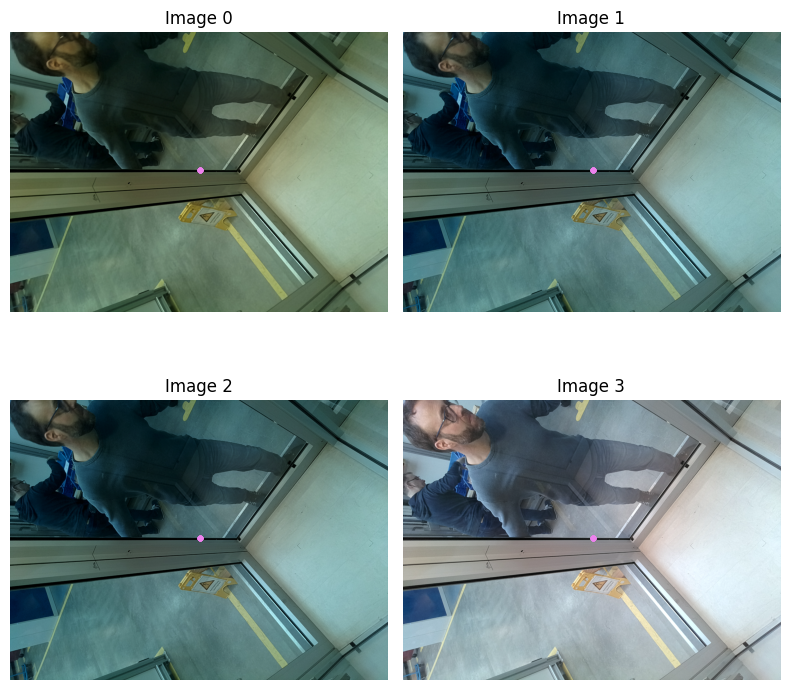

In [75]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np

yellow_cmap = ListedColormap(['yellow'])

fig, axes = plt.subplots(2, 2, figsize=(8, 8))
axes = axes.ravel()

# pick any 16 images you want
indices = range(4)  # or choose your own list

for i, ax in zip(indices, axes):

    img = images[i]
    inside_mask = inside_masks[i]

    # show the image
    ax.imshow(img)

    # reference points
    ax.scatter(df_ref["u_from_world"], df_ref["v_from_world"], s=2, c="blue")

    # axis-aligned bbox vertices
    ax.scatter(u_aabb, v_aabb, s=10, c="violet")

    # draw faces
    for f in faces:
        poly = Polygon(aabb_img[f], closed=True,
                       edgecolor='purple', facecolor='violet', alpha=0.3)
        ax.add_patch(poly)

    # overlay inside_mask only where True
    masked = np.ma.masked_where(~inside_mask, inside_mask)
    ax.imshow(masked, alpha=0.5, cmap=yellow_cmap)

    ax.set_title(f"Image {i}")
    ax.axis('off')

plt.tight_layout()
plt.show()


Rendering frames...


 68%|████████████████████████████████████▊                 | 30/44 [00:21<00:10,  1.38it/s]


IndexError: list index out of range

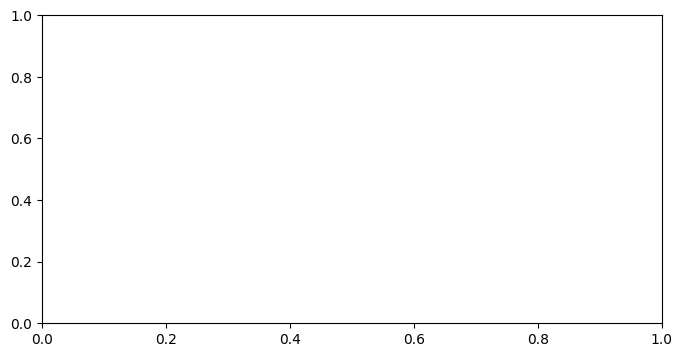

In [76]:
import imageio
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Polygon
import numpy as np
import tempfile
import os

def render_frame(idx, save_path):
    """Renders a single frame with overlays and saves it as a PNG."""
    fig, ax = plt.subplots(figsize=(8, 4))

    img = images[idx]
    inside_mask = inside_masks[idx]

    # Display image
    ax.imshow(img)

    # Reference points
    ax.scatter(df_ref["u_from_world"], df_ref["v_from_world"], s=2, c="blue")

    # AABB vertices
    ax.scatter(u_aabb, v_aabb, s=10, c="violet")

    # AABB faces
    for f in faces:
        poly = Polygon(aabb_img[f], closed=True,
                       edgecolor='purple', facecolor='violet', alpha=0.1)
        ax.add_patch(poly)

    # inside mask overlay (yellow)
    masked = np.ma.masked_where(~inside_mask, inside_mask)
    yellow_cmap = ListedColormap(['yellow'])
    ax.imshow(masked, alpha=0.3, cmap=yellow_cmap)

    ax.set_title(f"Frame {idx}")
    ax.axis('off')

    plt.tight_layout()
    plt.savefig(save_path, dpi=80)
    plt.close(fig)



# -------------------------------
# Create the GIF
# -------------------------------
def create_gif(output_path="aabb_overlay.gif", indices=range(32), fps=5):
    frames = []

    with tempfile.TemporaryDirectory() as tmpdir:
        print("Rendering frames...")
        for idx in tqdm(indices):
            frame_path = os.path.join(tmpdir, f"frame_{idx:03d}.png")
            render_frame(idx, frame_path)
            frames.append(imageio.imread(frame_path))

        print(f"Saving GIF to {output_path}...")
        imageio.mimsave(output_path, frames, fps=fps)

    print("GIF created!")



# Run it:
create_gif("overlay_44_frames.gif", indices=range(44), fps=5)